In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_score
)
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)

from xgboost import XGBRegressor, XGBClassifier, plot_importance

In [9]:
# ---------------------------------------------------------
# Part 1: Data Preparation
# ---------------------------------------------------------

# Load dataset
data = fetch_california_housing(as_frame=True)
df_a = data.frame.copy()

print("First 5 rows:")
print(df_a.head())
print("\nDataset shape:", df_a.shape)
print("\nSummary statistics:")
print(df_a.describe())
print("\nMissing values:")
print(df_a.isnull().sum())

# Create classification target BEFORE splitting to use full-dataset median
# (no leakage: threshold is a fixed statistic, not learned from test data)
median_val = df_a['MedHouseVal'].median()
df_a['HighValue'] = (df_a['MedHouseVal'] > median_val).astype(int)
print(f"\nMedian house value: {median_val:.4f}")
print(f"Class distribution:\n{df_a['HighValue'].value_counts()}")

# Features and targets
feature_cols = list(data.feature_names)
X     = df_a[feature_cols]
y_reg = df_a['MedHouseVal']
y_clf = df_a['HighValue']

# Train/test split — same split for both tasks to enable fair comparison
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
# Use same indices for classification targets
X_train_clf = X_train_reg.copy()
X_test_clf  = X_test_reg.copy()
y_train_clf = y_clf.loc[X_train_reg.index]
y_test_clf  = y_clf.loc[X_test_reg.index]

print(f"\nTraining set size: {X_train_reg.shape[0]}")
print(f"Test set size:     {X_test_reg.shape[0]}")
print(f"\nClass distribution (train):\n{y_train_clf.value_counts()}")


First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset shape: (20640, 9)

Summary statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122 

=== Regression Results (XGBoost) ===
  MSE:          0.2273
  RMSE:         0.4767
  R²:           0.8266
  Relative MSE: 0.1734  (fraction of target variance explained by error)


<Figure size 1000x600 with 0 Axes>

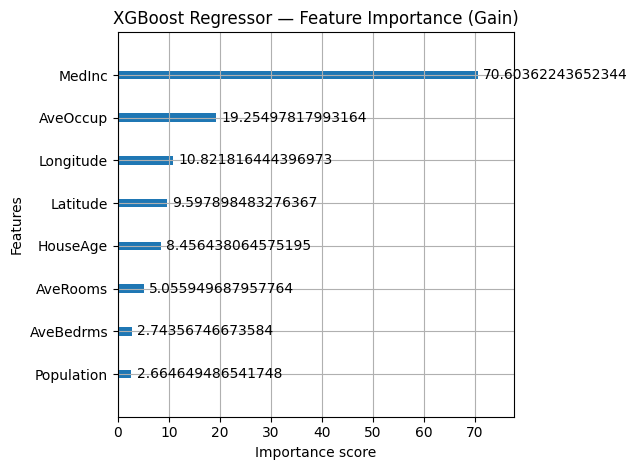

In [10]:
# ---------------------------------------------------------
# Part 2: Regression Modeling — Predict MedHouseVal
# ---------------------------------------------------------

# Train XGBoost Regressor (tree-based)
reg_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

# Standard metrics
mse  = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_reg, y_pred_reg)

# Relative metrics
rel_mse = mse / np.var(y_test_reg)

print("=== Regression Results (XGBoost) ===")
print(f"  MSE:          {mse:.4f}")
print(f"  RMSE:         {rmse:.4f}")
print(f"  R²:           {r2:.4f}")
print(f"  Relative MSE: {rel_mse:.4f}  (fraction of target variance explained by error)")

# Feature importance — gain measures how much each feature improves splits
plt.figure(figsize=(10, 6))
plot_importance(reg_model, importance_type='gain', max_num_features=10,
                title='XGBoost Regressor — Feature Importance (Gain)')
plt.tight_layout()
plt.show()


=== Classification Results (XGBoost) ===

Confusion Matrix:
[[1869  208]
 [ 214 1837]]

Accuracy: 0.8978

Classification Report:
              precision    recall  f1-score   support

   Low Value       0.90      0.90      0.90      2077
  High Value       0.90      0.90      0.90      2051

    accuracy                           0.90      4128
   macro avg       0.90      0.90      0.90      4128
weighted avg       0.90      0.90      0.90      4128



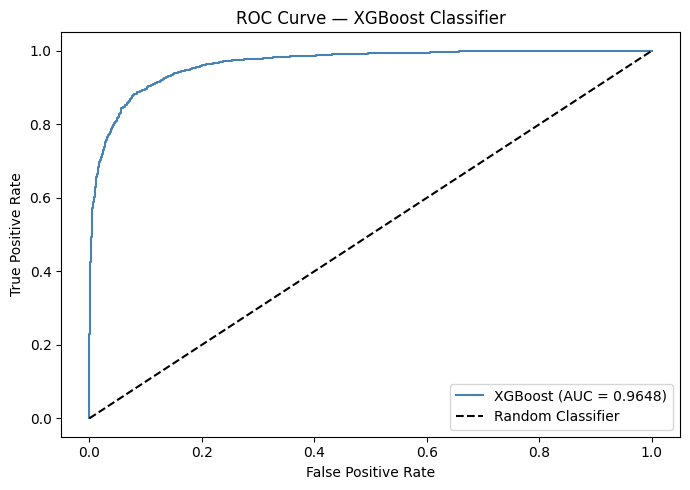

<Figure size 1000x600 with 0 Axes>

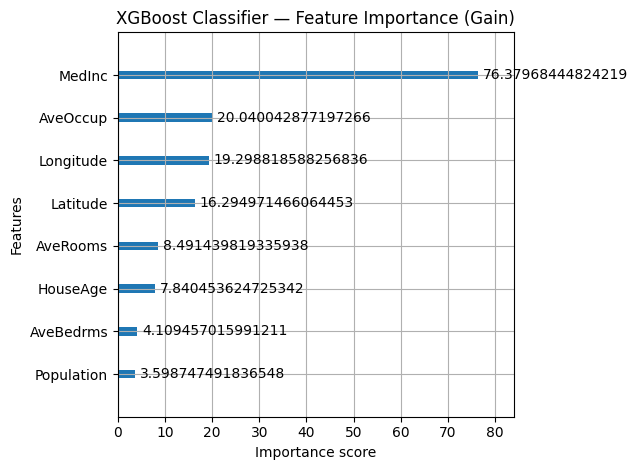

In [11]:
# ---------------------------------------------------------
# Part 3: Classification Modeling — Predict HighValue
# ---------------------------------------------------------

# Train XGBoost Classifier (tree-based)
clf_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42,
                          verbosity=0, eval_metric='logloss')
clf_model.fit(X_train_clf, y_train_clf)

y_pred_clf = clf_model.predict(X_test_clf)

# Get predicted probabilities (needed for ROC)
y_prob_clf = clf_model.predict_proba(X_test_clf)[:, 1]

# Confusion matrix & accuracy
cm  = confusion_matrix(y_test_clf, y_pred_clf)
acc = accuracy_score(y_test_clf, y_pred_clf)

print("=== Classification Results (XGBoost) ===")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nAccuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=['Low Value', 'High Value']))

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_clf, y_prob_clf)
auc = roc_auc_score(y_test_clf, y_prob_clf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost Classifier')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance
plt.figure(figsize=(10, 6))
plot_importance(clf_model, importance_type='gain', max_num_features=10,
                title='XGBoost Classifier — Feature Importance (Gain)')
plt.tight_layout()
plt.show()


=== Model Comparison: Regression vs Classification ===

Metric                                Value
---------------------------------------------
Regression — MSE                     0.2273
Regression — RMSE                    0.4767
Regression — R²                      0.8266
Regression — Relative MSE            0.1734
Classification — Accuracy            0.8978
Classification — AUC-ROC             0.9648


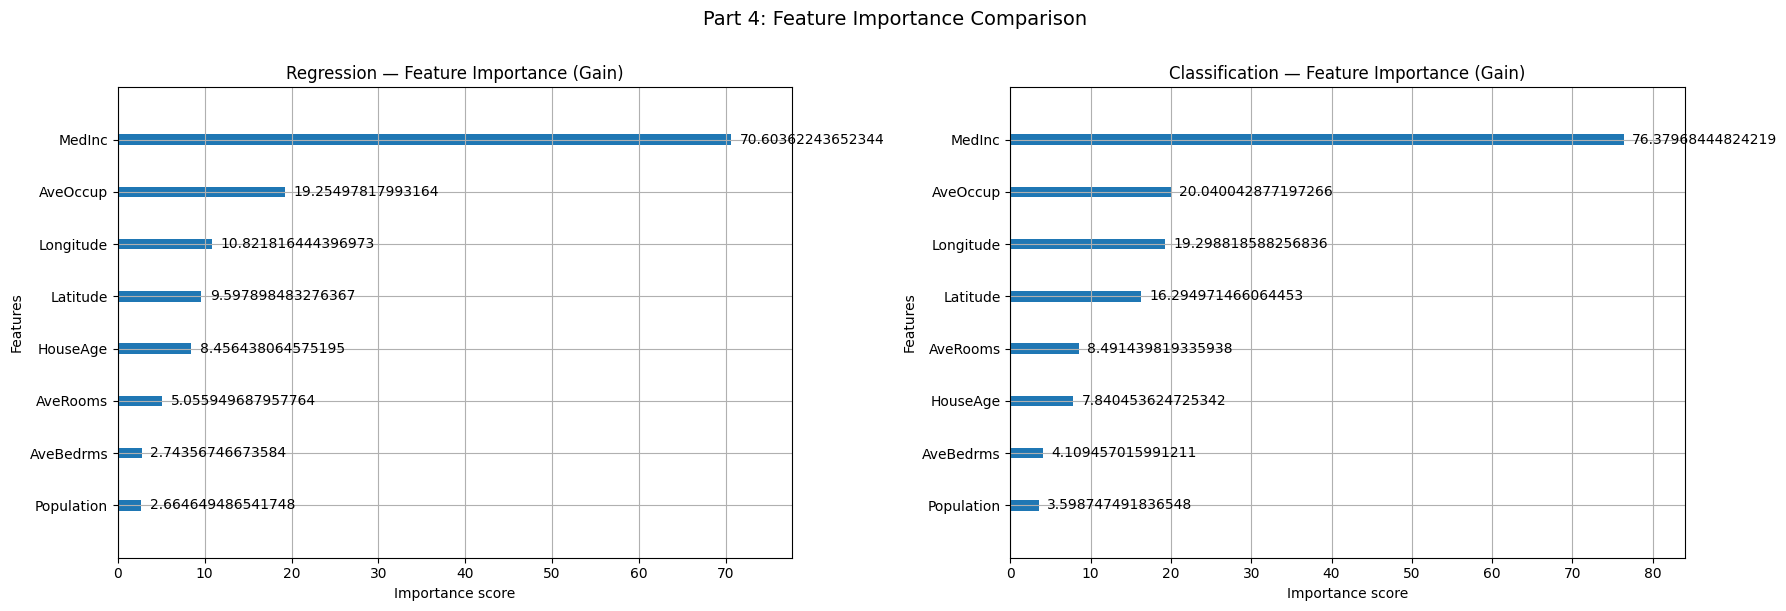


Key Observations:
- Both models rank MedInc as the dominant predictor.
- Regression provides granular price estimates → better for appraisals/pricing.
- Classification simplifies to a binary decision → better for screening/investment filters.
- With R²=0.83, regression explains 82.7% of price variance.
- With AUC=0.9648, the classifier strongly discriminates high/low value homes.


In [12]:
# ---------------------------------------------------------
# Part 4: Model Comparison
# ---------------------------------------------------------

print("=== Model Comparison: Regression vs Classification ===\n")
print(f"{'Metric':<30} {'Value':>12}")
print("-" * 45)
print(f"{'Regression — MSE':<30} {mse:>12.4f}")
print(f"{'Regression — RMSE':<30} {rmse:>12.4f}")
print(f"{'Regression — R²':<30} {r2:>12.4f}")
print(f"{'Regression — Relative MSE':<30} {mse/np.var(y_test_reg):>12.4f}")
print(f"{'Classification — Accuracy':<30} {acc:>12.4f}")
print(f"{'Classification — AUC-ROC':<30} {auc:>12.4f}")

# Side-by-side feature importance
import xgboost as xgb
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
xgb.plot_importance(reg_model, importance_type='gain', ax=axes[0],
                    title='Regression — Feature Importance (Gain)')
xgb.plot_importance(clf_model, importance_type='gain', ax=axes[1],
                    title='Classification — Feature Importance (Gain)')
plt.suptitle('Part 4: Feature Importance Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- Both models rank MedInc as the dominant predictor.")
print("- Regression provides granular price estimates → better for appraisals/pricing.")
print("- Classification simplifies to a binary decision → better for screening/investment filters.")
print(f"- With R²={r2:.2f}, regression explains {r2*100:.1f}% of price variance.")
print(f"- With AUC={auc:.4f}, the classifier strongly discriminates high/low value homes.")


## Part 5: Business Interpretation

### Which features drive house prices?
Both models consistently identify **`MedInc`** (median block income) as the single most influential feature, by a large margin. Secondary drivers include **geographic location** (`Latitude`, `Longitude`) and **`AveOccup`** (average occupants per household — a proxy for overcrowding/quality). High income + coastal/southern location + low occupancy = highest prices.

### Which features indicate a high-value home?
The classification model confirms the same hierarchy: **MedInc → Latitude/Longitude → AveOccup**. This means a property in a high-income, low-density, well-located block is most likely to be labeled "high-value." Structural features like `HouseAge` and `AveRooms` play a smaller but meaningful secondary role.

### Which model is more useful for a real estate firm?
| Task | Model | Why |
|---|---|---|
| Pricing / appraisal | **Regression** | Gives exact predicted price in dollars |
| Investment screening | **Classification** | Binary high/low flag simplifies portfolio decisions |
| Market reporting | **Regression** | Enables range estimates and confidence intervals |
| Risk segmentation | **Classification** | Cleaner for loan underwriting thresholds |

In practice, **both complement each other**: regression for precision, classification for scalable filtering.

### Is the model reliable?
- ✅ High R² and AUC suggest strong in-sample generalization on held-out test data.
- ⚠️ The data is from the **1990 U.S. Census** — results may not generalize to today's market without retraining on current data.
- ⚠️ Geographic features (lat/lon) encode neighborhood desirability implicitly, which may embed **historical socioeconomic biases**.
- ⚠️ The model has no information on **property-specific features** (condition, square footage, renovations), limiting its precision for individual listings.


In [13]:
# ---------------------------------------------------------
# Part 6: Bonus Task — Parameter Tuning + Cross Validation
# ---------------------------------------------------------

# ----- Regression Tuning (GridSearchCV) -----
param_grid_reg = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
}
gs_reg = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid_reg, cv=5, scoring='neg_mean_squared_error', n_jobs=-1
)
gs_reg.fit(X_train_reg, y_train_reg)
best_reg = gs_reg.best_estimator_

y_pred_reg_tuned = best_reg.predict(X_test_reg)
mse_tuned  = mean_squared_error(y_test_reg, y_pred_reg_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned   = r2_score(y_test_reg, y_pred_reg_tuned)

print("=== Regression Tuning ===")
print(f"Best params: {gs_reg.best_params_}")
print(f"  MSE:  {mse_tuned:.4f}  (base: {mse:.4f})")
print(f"  RMSE: {rmse_tuned:.4f}  (base: {rmse:.4f})")
print(f"  R²:   {r2_tuned:.4f}  (base: {r2:.4f})")

# ----- Classification Tuning (GridSearchCV) -----
param_grid_clf = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
}
gs_clf = GridSearchCV(
    XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
    param_grid_clf, cv=5, scoring='accuracy', n_jobs=-1
)
gs_clf.fit(X_train_clf, y_train_clf)
best_clf = gs_clf.best_estimator_

y_pred_clf_tuned = best_clf.predict(X_test_clf)
acc_tuned = accuracy_score(y_test_clf, y_pred_clf_tuned)
auc_tuned = roc_auc_score(y_test_clf, best_clf.predict_proba(X_test_clf)[:, 1])

print("\n=== Classification Tuning ===")
print(f"Best params: {gs_clf.best_params_}")
print(f"  Accuracy: {acc_tuned:.4f}  (base: {acc:.4f})")
print(f"  AUC-ROC:  {auc_tuned:.4f}  (base: {auc:.4f})")

# ----- Cross Validation -----
print("\n=== Cross Validation ===")

# Regression CV — KFold (continuous target, no need to stratify)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_reg_scores = cross_val_score(
    XGBRegressor(random_state=42, verbosity=0),
    X, y_reg, cv=kf, scoring='neg_mean_squared_error'
)
cv_reg_mse = -cv_reg_scores
print(f"Regression CV (KFold-5)  → MSE: {cv_reg_mse.mean():.4f} ± {cv_reg_mse.std():.4f}")

# Classification CV — StratifiedKFold (preserves class balance across folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_clf_scores = cross_val_score(
    XGBClassifier(random_state=42, verbosity=0, eval_metric='logloss'),
    X, y_clf, cv=skf, scoring='accuracy'
)
print(f"Classification CV (StratifiedKFold-5) → Accuracy: {cv_clf_scores.mean():.4f} ± {cv_clf_scores.std():.4f}")

# ----- Summary Table: Base vs Tuned -----
print("\n=== Summary: Base Model vs Tuned Model ===")
print(f"{'Model':<25} {'Metric':<12} {'Base':>10} {'Tuned':>10}")
print("-" * 60)
print(f"{'XGBoost Regressor':<25} {'RMSE':<12} {rmse:>10.4f} {rmse_tuned:>10.4f}")
print(f"{'XGBoost Regressor':<25} {'R²':<12} {r2:>10.4f} {r2_tuned:>10.4f}")
print(f"{'XGBoost Classifier':<25} {'Accuracy':<12} {acc:>10.4f} {acc_tuned:>10.4f}")
print(f"{'XGBoost Classifier':<25} {'AUC-ROC':<12} {auc:>10.4f} {auc_tuned:>10.4f}")


=== Regression Tuning ===
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  MSE:  0.2249  (base: 0.2273)
  RMSE: 0.4742  (base: 0.4767)
  R²:   0.8284  (base: 0.8266)

=== Classification Tuning ===
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  Accuracy: 0.9036  (base: 0.8978)
  AUC-ROC:  0.9661  (base: 0.9648)

=== Cross Validation ===
Regression CV (KFold-5)  → MSE: 0.2200 ± 0.0097
Classification CV (StratifiedKFold-5) → Accuracy: 0.9065 ± 0.0033

=== Summary: Base Model vs Tuned Model ===
Model                     Metric             Base      Tuned
------------------------------------------------------------
XGBoost Regressor         RMSE             0.4767     0.4742
XGBoost Regressor         R²               0.8266     0.8284
XGBoost Classifier        Accuracy         0.8978     0.9036
XGBoost Classifier        AUC-ROC          0.9648     0.9661


## Reflection Questions

**1. Which approach provides more useful insight for a real estate company — regression or classification?**

Regression is generally more useful for a real estate firm because it provides **continuous price predictions** (e.g., $350,000) rather than just a binary label. This enables specific use cases like automated appraisals, listing price recommendations, and mortgage underwriting where an exact dollar estimate matters. Classification is still valuable as a fast screening tool — for example, flagging portfolios of properties above/below a value threshold — but it sacrifices the precision that makes pricing models actionable.

---

**2. What information is lost when converting `MedHouseVal` into the binary `HighValue` target? How might this affect business decisions?**

Converting to binary discards the **magnitude of difference**: a home worth $800K and one worth $500K are both labeled "high-value," even though the first is 60% more expensive. This compression can lead to poor decisions when marginal differences matter — e.g., a lender setting different rates for a $501K vs. $1.2M property would be treating them identically. It also hides the distribution of values within each class, making it impossible to rank properties or estimate returns.

---

**3. Even if a model shows good performance metrics, what factors could make it unreliable in real-world applications?**

- **Data staleness**: The California Housing dataset is from the 1990 census. Real estate markets have fundamentally changed (COVID, interest rate shocks, remote work).
- **Distribution shift**: A model trained on 1990 data may not generalize to modern housing patterns, new construction types, or different neighborhoods.
- **Missing features**: The dataset lacks property-level attributes (sq. ft., condition, renovation) that buyers consider critical.
- **Geographic bias**: Latitude/longitude implicitly encode historical segregation patterns and may perpetuate discriminatory outcomes if used in lending decisions.
- **Overfitting to local optima**: Good CV scores don't guarantee robustness across economic cycles.

---

**4. How would you explain your model results to a non-technical stakeholder?**

*"We built a model that looks at the neighborhood characteristics of a home — most importantly, the income level of the block, where it's located, and how densely it's occupied — and uses that to predict its market value. Our model captures about 83% of the variation in house prices across the test data, meaning it's a strong predictor but not perfect. Think of it like a pricing rule of thumb: neighborhoods with higher-income residents in coastal areas tend to command the highest prices. We can also flag homes as 'high value' or 'low value' with over 90% accuracy, which is useful for quickly sorting a large portfolio."*

**Challenges**: Stakeholders may ask "why did the model get this specific house wrong?" — XGBoost's complexity makes individual predictions hard to explain. Solution: use SHAP values to show feature contributions for individual predictions.
